In [1]:
import pandas as pd

df = pd.read_csv("../data/features/features_usda_clr.csv")
print(df.shape)

(47, 17)


In [4]:
# Inspect the food description and protein content
df[["description", "Protein_g"]].head(8)

,description,Protein_g
0,"Milk, reduced fat, fluid, 2% milkfat, with add...",3.35
1,"Broccoli, raw",2.57
2,"Milk, lowfat, fluid, 1% milkfat, with added vi...",3.38
3,"Milk, nonfat, fluid, with added vitamin A and ...",3.43
4,"Milk, whole, 3.25% milkfat, with added vitamin D",3.28
5,"Cheese, ricotta, whole milk",7.81
6,"Sausage, breakfast sausage, beef, pre-cooked, ...",13.30
7,"Sausage, turkey, breakfast links, mild, raw",16.70


In [5]:
df["Protein_g"].describe()

count    47.000000
mean     10.818891
std      10.200538
min       1.060000
25%       3.355000
50%       7.810000
75%      15.951950
max      51.100000
Name: Protein_g, dtype: float64

Matplotlib is building the font cache; this may take a moment.


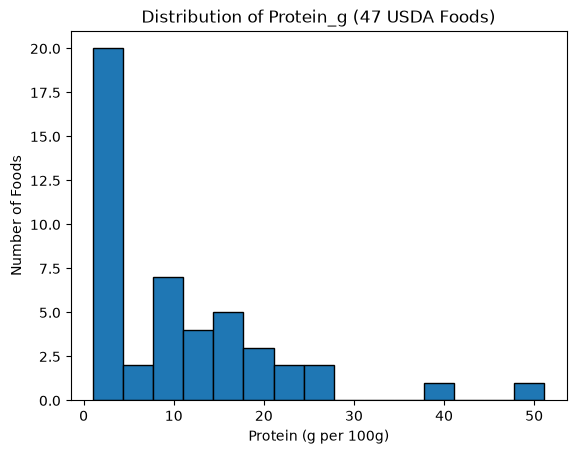

In [6]:
# Cell 4: Visualize how protein is distributed across the 47 foods
import matplotlib.pyplot as plt

df["Protein_g"].plot(kind="hist", bins=15, edgecolor="black")
plt.title("Distribution of Protein_g (47 USDA Foods)")
plt.xlabel("Protein (g per 100g)")
plt.ylabel("Number of Foods")
plt.show()

In [7]:
# Look at the raw amino acid ratios for the first 3 foods
amino_cols = [c for c in df.columns if c.startswith("clr_")]
df[["description"] + amino_cols[:4]].head(3)

,description,clr_His,clr_Ile,clr_Leu,clr_Lys
0,"Milk, reduced fat, fluid, 2% milkfat, with add...",-0.284239,0.273932,0.934771,0.800813
1,"Broccoli, raw",-0.164119,0.127792,0.618156,0.663618
2,"Milk, lowfat, fluid, 1% milkfat, with added vi...",-0.303309,0.260626,0.936382,0.831671


In [8]:
df[["description", "clr_Leu"]].head(1)

,description,clr_Leu
0,"Milk, reduced fat, fluid, 2% milkfat, with add...",0.934771


In [9]:
df[["description", "clr_Leu", "clr_Met", "clr_Cys"]].head(2)

,description,clr_Leu,clr_Met,clr_Cys
0,"Milk, reduced fat, fluid, 2% milkfat, with add...",0.934771,-0.390723,-1.324011
1,"Broccoli, raw",0.618156,-0.604070,-0.909451


In [10]:
# Select all amino acid columns for Milk (row 0) and find the lowest one
amino_cols = [c for c in df.columns if c.startswith("clr_")]
df.loc[0, amino_cols].sort_values().head(3)

clr_Cys   -1.324011
clr_Trp   -1.141689
clr_Met   -0.390723
Name: 0, dtype: float64

In [11]:
df.loc[1, amino_cols].sort_values().head(3)

clr_Cys   -0.909451
clr_Trp   -0.745148
clr_Met   -0.604070
Name: 1, dtype: float64

In [12]:
# For every food, find which amino acid was lowest, then count them up
df[amino_cols].idxmin(axis=1).value_counts()

clr_Trp    25
clr_Cys    16
clr_Met     6
Name: count, dtype: int64

In [13]:
# FAO/WHO 2013 Reference Pattern (mg of amino acid per gram of protein)
# for older children, adolescents, and adults
fao_reference = {
    "His": 16.0,  # Histidine
    "Ile": 30.0,  # Isoleucine
    "Leu": 59.0,  # Leucine
    "Lys": 45.0,  # Lysine
    "SAA": 22.0,  # Sulfur Amino Acids (Methionine + Cysteine combined)
    "AAA": 38.0,  # Aromatic Amino Acids (Phenylalanine + Tyrosine)
    "Thr": 23.0,  # Threonine
    "Trp": 6.0,   # Tryptophan
    "Val": 39.0   # Valine
}

# Display the requirement for Leucine vs Tryptophan
print(f"Leucine needed: {fao_reference['Leu']} mg/g")
print(f"Tryptophan needed: {fao_reference['Trp']} mg/g")

Leucine needed: 59.0 mg/g
Tryptophan needed: 6.0 mg/g


In [14]:
df.columns.tolist()


['fdc_id',
 'description',
 'food_category_id',
 'Protein_g',
 'SAA',
 'AAA',
 'clr_His',
 'clr_Ile',
 'clr_Leu',
 'clr_Lys',
 'clr_Met',
 'clr_Cys',
 'clr_Phe',
 'clr_Tyr',
 'clr_Thr',
 'clr_Trp',
 'clr_Val']

In [15]:
from pathlib import Path
list(Path("../data").rglob("*.csv"))

[PosixPath('../data/features/features_clr_transformed.csv'),
 PosixPath('../data/features/features_usda_clr.csv'),
 PosixPath('../data/processed/reference_scoring_patterns.csv'),
 PosixPath('../data/processed/food_amino_acid_profiles.csv'),
 PosixPath('../data/processed/food_diaas_calculated.csv'),
 PosixPath('../data/processed/usda_amino_acid_profiles.csv'),
 PosixPath('../data/raw/usda_foundation/FoodData_Central_foundation_food_csv_2024-04-18/food_calorie_conversion_factor.csv'),
 PosixPath('../data/raw/usda_foundation/FoodData_Central_foundation_food_csv_2024-04-18/food_nutrient_conversion_factor.csv'),
 PosixPath('../data/raw/usda_foundation/FoodData_Central_foundation_food_csv_2024-04-18/food_attribute_type.csv'),
 PosixPath('../data/raw/usda_foundation/FoodData_Central_foundation_food_csv_2024-04-18/food_attribute.csv'),
 PosixPath('../data/raw/usda_foundation/FoodData_Central_foundation_food_csv_2024-04-18/market_acquisition.csv'),
 PosixPath('../data/raw/usda_foundation/FoodDa

In [16]:
df_raw = pd.read_csv("../data/processed/usda_amino_acid_profiles.csv")
df_raw.head(2)

,fdc_id,description,food_category_id,Cys,His,Ile,Leu,Lys,Met,Phe,Protein_g,Thr,Trp,Tyr,Val,SAA,AAA
0,321359,"Milk, reduced fat, fluid, 2% milkfat, with add...",1.0,10.447761,29.552239,51.641791,100.000000,87.462687,26.567164,48.656716,3.35,48.358209,12.537313,49.253731,63.582090,37.014925,97.910448
1,321900,"Broccoli, raw",11.0,10.894942,22.957198,30.739300,50.194553,52.529183,14.785992,45.525292,2.57,34.241245,12.840467,19.455253,48.638132,25.680934,64.980545


In [17]:
# Match each amino acid to its FAO requirement
milk_row = df_raw.iloc[0]

scores = {
    "His": milk_row["His"] / fao_reference["His"],
    "Ile": milk_row["Ile"] / fao_reference["Ile"],
    "Leu": milk_row["Leu"] / fao_reference["Leu"],
    "Lys": milk_row["Lys"] / fao_reference["Lys"],
    "SAA": milk_row["SAA"] / fao_reference["SAA"],
    "AAA": milk_row["AAA"] / fao_reference["AAA"],
    "Thr": milk_row["Thr"] / fao_reference["Thr"],
    "Trp": milk_row["Trp"] / fao_reference["Trp"],
    "Val": milk_row["Val"] / fao_reference["Val"],
}

# Convert to a Pandas Series and sort from lowest to highest score
pd.Series(scores).sort_values()

Val    1.630310
SAA    1.682497
Leu    1.694915
Ile    1.721393
His    1.847015
Lys    1.943615
Trp    2.089552
Thr    2.102531
AAA    2.576591
dtype: float64

In [18]:
# Calculate amino acid scores for Broccoli (Row 1)
broccoli_row = df_raw.iloc[1]

broccoli_scores = {
    "His": broccoli_row["His"] / fao_reference["His"],
    "Ile": broccoli_row["Ile"] / fao_reference["Ile"],
    "Leu": broccoli_row["Leu"] / fao_reference["Leu"],
    "Lys": broccoli_row["Lys"] / fao_reference["Lys"],
    "SAA": broccoli_row["SAA"] / fao_reference["SAA"],
    "AAA": broccoli_row["AAA"] / fao_reference["AAA"],
    "Thr": broccoli_row["Thr"] / fao_reference["Thr"],
    "Trp": broccoli_row["Trp"] / fao_reference["Trp"],
    "Val": broccoli_row["Val"] / fao_reference["Val"],
}

pd.Series(broccoli_scores).sort_values()

Leu    0.850755
Ile    1.024643
Lys    1.167315
SAA    1.167315
Val    1.247132
His    1.434825
Thr    1.488750
AAA    1.710014
Trp    2.140078
dtype: float64

In [19]:
# 1. Map each column in df_raw to its FAO requirement
ratios = pd.DataFrame()
ratios["His"] = df_raw["His"] / fao_reference["His"]
ratios["Ile"] = df_raw["Ile"] / fao_reference["Ile"]
ratios["Leu"] = df_raw["Leu"] / fao_reference["Leu"]
ratios["Lys"] = df_raw["Lys"] / fao_reference["Lys"]
ratios["SAA"] = df_raw["SAA"] / fao_reference["SAA"]
ratios["AAA"] = df_raw["AAA"] / fao_reference["AAA"]
ratios["Thr"] = df_raw["Thr"] / fao_reference["Thr"]
ratios["Trp"] = df_raw["Trp"] / fao_reference["Trp"]
ratios["Val"] = df_raw["Val"] / fao_reference["Val"]

# 2. Find the lowest ratio for every food (the limiting score)
df_raw["limiting_amino_acid"] = ratios.idxmin(axis=1)
df_raw["target_aas"] = ratios.min(axis=1)

# 3. View the description, the limiting amino acid, and the target score
df_raw[["description", "limiting_amino_acid", "target_aas"]].head(6)

,description,limiting_amino_acid,target_aas
0,"Milk, reduced fat, fluid, 2% milkfat, with add...",Val,1.630310
1,"Broccoli, raw",Leu,0.850755
2,"Milk, lowfat, fluid, 1% milkfat, with added vi...",Val,1.593081
3,"Milk, nonfat, fluid, with added vitamin A and ...",Val,1.659565
4,"Milk, whole, 3.25% milkfat, with added vitamin D",Val,1.618199
5,"Cheese, ricotta, whole milk",Val,1.067008


In [20]:
# Check the summary statistics and distribution of the real target
print(df_raw["target_aas"].describe())
print("\nMost common limiting amino acids across the dataset:")
print(df_raw["limiting_amino_acid"].value_counts())

count    47.000000
mean      1.083707
std       0.375100
min       0.207867
25%       0.840490
50%       1.025822
75%       1.367869
max       1.659565
Name: target_aas, dtype: float64

Most common limiting amino acids across the dataset:
limiting_amino_acid
Val    24
Lys    11
SAA     5
Leu     4
His     2
Trp     1
Name: count, dtype: int64


In [21]:
# Inspect the foods with the lowest protein quality scores
df_raw.sort_values(by="target_aas")[["description", "limiting_amino_acid", "target_aas"]].head(3)

,description,limiting_amino_acid,target_aas
11,"Nectarines, raw",Leu,0.207867
8,"Mustard, prepared, yellow",Trp,0.392157
21,"Figs, dried, uncooked",Lys,0.545455


In [22]:
target_df = df_raw[["fdc_id", "target_aas", "limiting_amino_acid"]]
model_df = pd.merge(df, target_df, on = "fdc_id")
model_df[["description", "limiting_amino_acid", "target_aas", "clr_Leu", "clr_Lys"]]

,description,limiting_amino_acid,target_aas,clr_Leu,clr_Lys
0,"Milk, reduced fat, fluid, 2% milkfat, with add...",Val,1.630310,0.934771,0.800813
1,"Broccoli, raw",Leu,0.850755,0.618156,0.663618
2,"Milk, lowfat, fluid, 1% milkfat, with added vi...",Val,1.593081,0.936382,0.831671
3,"Milk, nonfat, fluid, with added vitamin A and ...",Val,1.659565,0.923610,0.784712
4,"Milk, whole, 3.25% milkfat, with added vitamin D",Val,1.618199,0.929005,0.817956
5,"Cheese, ricotta, whole milk",Val,1.067008,1.013749,0.832700
6,"Sausage, breakfast sausage, beef, pre-cooked, ...",Val,1.021785,0.833790,0.855067
7,"Sausage, turkey, breakfast links, mild, raw",Val,0.998004,0.819428,0.947906
8,"Mustard, prepared, yellow",Trp,0.392157,0.932580,0.834140
9,"Figs, dried, uncooked",Lys,0.545455,0.764028,0.404888


In [23]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# 1. Define inputs (X) and target (y)
feature_cols = [c for c in model_df.columns if c.startswith("clr_")]
X = model_df[feature_cols]
y = model_df["target_aas"]

# 2. Set up 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = Ridge(alpha=1.0)

# 3. Score the model on unseen test folds
scores = cross_val_score(model, X, y, cv=cv, scoring="r2")

print("R² scores across the 5 folds:", np.round(scores, 3))
print("Mean R² score:", round(scores.mean(), 3))

R² scores across the 5 folds: [0.562 0.206 0.263 0.691 0.384]
Mean R² score: 0.421


In [24]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize a Random Forest regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Score using the exact same 5 folds
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring="r2")

print("Random Forest fold scores:", np.round(rf_scores, 3))
print("Mean Random Forest R²:", round(rf_scores.mean(), 3))

Random Forest fold scores: [0.864 0.623 0.498 0.844 0.663]
Mean Random Forest R²: 0.698


In [25]:
# Train RF on the full 47-sample dataset to inspect feature importances
rf.fit(X, y)

# Create a ranked table of feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
round(importances, 3)

clr_Tyr    0.290
clr_His    0.134
clr_Met    0.125
clr_Cys    0.123
clr_Val    0.116
clr_Lys    0.051
clr_Phe    0.050
clr_Thr    0.041
clr_Ile    0.025
clr_Leu    0.023
clr_Trp    0.021
dtype: float64

In [26]:
import pandas as pd
from pathlib import Path

for path in sorted(Path("../data/processed").glob("*.csv")):
    df_temp = pd.read_csv(path)
    print(f"{path.name:35} -> {df_temp.shape[0]} rows, {df_temp.shape[1]} columns")

food_amino_acid_profiles.csv        -> 12 rows, 24 columns
food_diaas_calculated.csv           -> 12 rows, 36 columns
reference_scoring_patterns.csv      -> 3 rows, 15 columns
usda_amino_acid_profiles.csv        -> 47 rows, 17 columns


In [29]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(rf, X, y, cv=cv)

# build the diagonostics table 
diagnostics = pd.DataFrame({
    "description": model_df["description"],
    "limiting_aa": model_df["limiting_amino_acid"],
    "actual_aas": y,
    "predicted_aas": y_pred_cv,
    "abs_error": np.abs(y - y_pred_cv),
    "residual": y - y_pred_cv  # positive = model underpredicted, negative = overpredicted
})

# 3. View the 5 foods with the largest prediction errors
diagnostics.sort_values(by="abs_error", ascending=False).head(5)

,description,limiting_aa,actual_aas,predicted_aas,abs_error,residual
11,"Nectarines, raw",Leu,0.207867,0.989403,0.781536,-0.781536
8,"Mustard, prepared, yellow",Trp,0.392157,1.039812,0.647655,-0.647655
42,"Flaxseed, ground",Lys,1.148943,0.816179,0.332764,0.332764
40,"Sesame butter, creamy",Lys,0.758393,1.079736,0.321342,-0.321342
43,"Nuts, pine nuts, raw",Lys,0.830225,1.148507,0.318281,-0.318281


In [30]:
# Train the production model on all 47 rows
final_rf = RandomForestRegressor(n_estimators=100, random_state=42)
final_rf.fit(X, y)

def evaluate_protein_quality(raw_amino_profile: dict) -> dict:
    """
    Given raw amino acid concentrations (mg/g protein),
    computes the CLR features, predicts the AAS, and determines
    the exact limiting amino acid against the FAO reference.
    """
    # 1. Compute exact ground truth AAS against FAO 2013
    scoring = {aa: raw_amino_profile[aa] / fao_reference[aa] for aa in fao_reference}
    exact_limiting_aa = min(scoring, key=scoring.get)
    exact_score = scoring[exact_limiting_aa]
    
    # 2. Compute CLR features matching training geometry
    # Log-ratio against geometric mean across essential amino acids
    aa_values = np.array([raw_amino_profile[col.replace("clr_", "")] for col in feature_cols])
    # Geometric mean
    geo_mean = np.exp(np.mean(np.log(aa_values)))
    clr_features = np.log(aa_values / geo_mean).reshape(1, -1)
    
    # 3. Model prediction
    predicted_score = final_rf.predict(clr_features)[0]
    
    return {
        "limiting_amino_acid": exact_limiting_aa,
        "exact_score": round(float(exact_score), 3),
        "predicted_score": round(float(predicted_score), 3),
        "is_complete_protein": exact_score >= 1.0
    }

# Test the function on a hypothetical sample (Egg-like profile)
sample_profile = {
    "His": 22.0, "Ile": 54.0, "Leu": 86.0, "Lys": 70.0,
    "Met": 30.0, "Cys": 23.0, "Phe": 53.0, "Tyr": 40.0,
    "Thr": 47.0, "Trp": 16.0, "Val": 66.0,
    "SAA": 53.0, "AAA": 93.0
}

evaluate_protein_quality(sample_profile)

/Users/avinash/Documents/vsc/diaas-protein-ml/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


{'limiting_amino_acid': 'His',
 'exact_score': 1.375,
 'predicted_score': 1.171,
 'is_complete_protein': True}

In [31]:
import joblib
from pathlib import Path

# Create models directory
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

# Package model and feature schema together
artifact = {
    "model": final_rf,
    "feature_cols": feature_cols,
    "fao_reference": fao_reference
}

joblib.dump(artifact, models_dir / "protein_rf_model.joblib")
print("Model artifact saved successfully to models/protein_rf_model.joblib")

Model artifact saved successfully to models/protein_rf_model.joblib
